# Hadoop

- Data sets that are so large or complex that traditional data processing application software is inadequate to deal with them.
- Data analysis requires massively parallel software running on several servers.
- **Volume, Variety, Velocity, Variability and Veracity** describe Big Data properties.

![https://github.com/veekaybee/data-lake-talk/](https://github.com/pnavaro/big-data/blob/master/notebooks/images/bigdata.png?raw=1)

![Hadoop Logo](https://github.com/pnavaro/big-data/blob/master/notebooks/images/hadoop.png?raw=1)
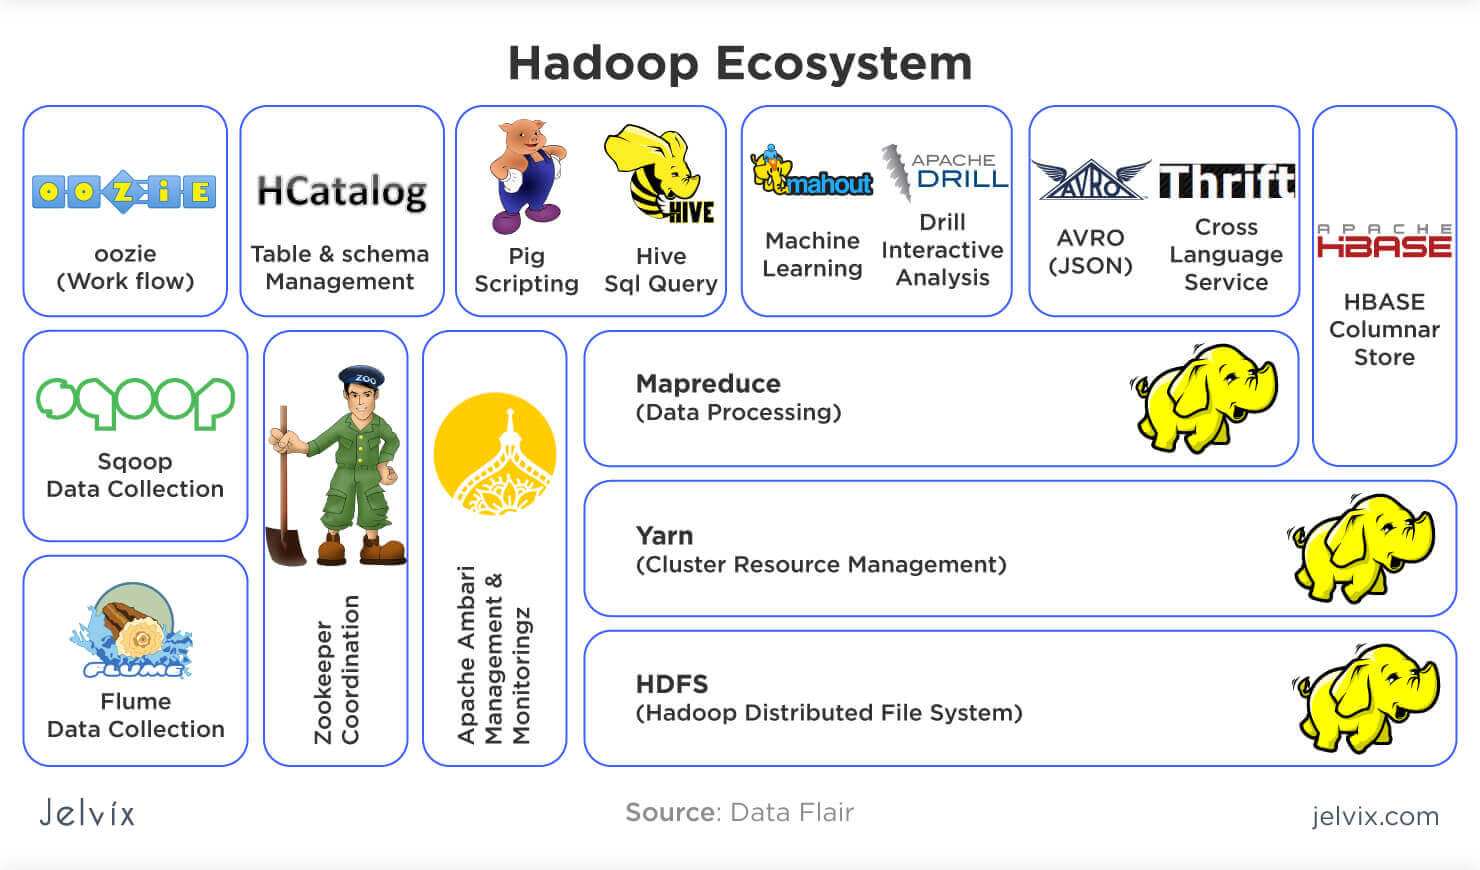

- Framework for running applications on large cluster.
- The Hadoop framework transparently provides applications both reliability and data motion.
- Hadoop implements the computational paradigm named **Map/Reduce**, where the application is divided into many small fragments of work, each of which may be executed or re-executed on any node in the cluster.
- It provides a distributed file system (HDFS) that stores data on the compute nodes, providing very high aggregate bandwidth across the cluster.
- Both MapReduce and the **Hadoop Distributed File System** are designed so that node failures are automatically handled by the framework.


## HDFS

* It is a distributed file systems.
* HDFS is highly fault-tolerant and is designed to be deployed on low-cost hardware.
* HDFS is suitable for applications that have large data sets.
* HDFS provides interfaces to move applications closer to where the data is located. The computation is much more efficient when the size of the data set is huge.
* HDFS consists of a single NameNode with a number of DataNodes which manage storage.
* HDFS exposes a file system namespace and allows user data to be stored in files.
    1. A file is split by the NameNode into blocks stored in DataNodes.
    2. The [NameNode](http://svmass2.mass.uhb.fr:50070) executes operations like opening, closing, and renaming files and directories.
    3. The [Secondary NameNode](http://svmass2.mass.uhb.fr:50090/status.html) stores information from **NameNode**.
    4. The **DataNodes** manage perform block creation, deletion, and replication upon instruction from the NameNode.
    5. The placement of replicas is optimized for data reliability, availability, and network bandwidth utilization.
    6. User data never flows through the NameNode.
* Files in HDFS are write-once and have strictly one writer at any time.
* The DataNode has no knowledge about HDFS files.

![hdfs blocks](https://github.com/pnavaro/big-data/blob/master/notebooks/images/hdfs-fonctionnement.jpg?raw=1)

The Name Node is not in the data path. The Name Node only provides the map of where data is and where data should go in the cluster (file system metadata).

## YARN

*YARN takes care of resource management and job scheduling/monitoring.*

- The **ResourceManager** is the ultimate authority that arbitrates resources among all the applications in the system. It has two components: **Scheduler** and **ApplicationsManager**.
- The **NodeManager** is the per-machine framework agent who is responsible for **Containers**, monitoring their resource usage (cpu, memory, disk, network) and reporting the same to the **ResourceManager/Scheduler**.

The per-application **ApplicationMaster** negotiates resources from the ResourceManager and working with the NodeManager(s) to execute and monitor the tasks.

- The **Scheduler** is responsible for allocating resources to the applications.

- The **ApplicationsManager** is responsible for accepting job-submissions, tracking their status and monitoring for progress.

![Yarn in Hadoop documentation](https://github.com/pnavaro/big-data/blob/master/notebooks/images/yarn_architecture.png?raw=1)
Source: http://hadoop.apache.org/docs/stable/hadoop-yarn/hadoop-yarn-site/yarn_architecture.gif

## Hadoop on Colab

Hadoop mainly works on 3 different modes:

*   Standalone Mode
*   Pseudo-distributed Mode
*   Fully-distributed Mode


**Standalone Mode**

By default, Hadoop is configured to run in a non distributed mode. It runs as a single Java process. Instead of HDFS, this mode utilizes the local file system. This mode is useful for debugging and there isn't any need to configure core-site.xml, hdfs-site.xml, mapred-site.xml, masters & slaves. Stand-alone mode is usually the fastest mode in Hadoop.

**Pseudo-distributed Mode**

Hadoop can also run on a single node in a Pseudo-distributed mode. In this mode, each daemon runs on separate java processes. In this mode custom configuration is required (core-site.xml, hdfs-site.xml, mapred-site.xml). Here HDFS is utilized for input and output. This mode of deployment is useful for testing and debugging purposes.

**Fully-distributed Mode**

This is the production mode of Hadoop. In this mode typically one machine in the cluster is designated as NameNode and another as Resource Manager exclusively. These are masters. All other nodes act as Data Node and Node Manager. These are the slaves. Configuration parameters and environment need to be specified for Hadoop Daemons.

Hadoop is a java programming-based data processing framework

OpenJDK is a development environment for building applications, applets, and components using the Java programming language.

In [1]:
#Checking the installed Java version
!java -version

openjdk version "1.8.0_462"
OpenJDK Runtime Environment (build 1.8.0_462-8u462-ga~us1-0ubuntu2~24.04.2-b08)
OpenJDK 64-Bit Server VM (build 25.462-b08, mixed mode)


In [2]:
%%sh 
sudo apt update
sudo apt-get install apt-utils 
sudo apt-get install openjdk-8-jdk

Hit:1 https://download.docker.com/linux/ubuntu noble InRelease
Hit:2 https://cli.github.com/packages stable InRelease
Hit:3 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble InRelease
Get:4 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:5 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:6 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-security InRelease [126 kB]


Get:7 https://archive.ubuntu.com/ubuntu noble InRelease [256 kB]
Get:8 https://packages.cloud.google.com/apt cloud-sdk InRelease [1620 B]
Get:9 https://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:10 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates/main amd64 Packages [1840 kB]
Get:11 http://deb.wakemeops.com/wakemeops stable InRelease [50.5 kB]
Get:12 https://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:13 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates/universe amd64 Packages [1924 kB]
Get:14 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Packages [2523 kB]
Get:15 https://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Get:16 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-security/main amd64 Packages [1474 kB]
Get:17 https://us-east-1.ec2.archive.ubuntu.com/ubuntu noble-security amd64 Contents (deb) [94.7 MB]
Get:18 https://archive.ubuntu.com/ubuntu noble/main amd64 Pa

debconf: delaying package configuration, since apt-utils is not installed


Fetched 216 kB in 0s (6852 kB/s)
Selecting previously unselected package apt-utils.
(Reading database ... 140671 files and directories currently installed.)
Preparing to unpack .../apt-utils_2.8.3_amd64.deb ...
Unpacking apt-utils (2.8.3) ...
Setting up apt-utils (2.8.3) ...
Processing triggers for man-db (2.12.0-4build2) ...
Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  alsa-topology-conf alsa-ucm-conf ca-certificates-java fonts-dejavu-extra
  java-common libasound2-data libasound2t64 libasyncns0 libatk-wrapper-java
  libatk-wrapper-java-jni libflac12t64 libgif7 libnspr4 libnss3 libpcsclite1
  libpulse0 libsndfile1 libxkbfile1 libxt-dev libxv1 libxxf86dga1
  openjdk-8-jdk-headless openjdk-8-jre openjdk-8-jre-headless x11-utils
Suggested packages:
  default-jre alsa-utils libasound2-plugins pcscd pulseaudio libxt-doc
  openjdk-8-demo openjdk-8-source visualvm libnss-mdns fonts-nanum
  fonts-ipafo

In [2]:
#Checking Java default version
!java -version

openjdk version "1.8.0_462"
OpenJDK Runtime Environment (build 1.8.0_462-8u462-ga~us1-0ubuntu2~24.04.2-b08)
OpenJDK 64-Bit Server VM (build 25.462-b08, mixed mode)


Creating Java related environment variables

The JAVA_HOME is an operating system environment variable points to the file system location where the JDK or JRE was installed.

In [3]:
#Finding the default Java path
!readlink -f /usr/bin/java | sed "s:bin/java::"

/usr/lib/jvm/java-8-openjdk-amd64/jre/


In [4]:
#Importing os module
import os
#Creating environment variables
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["JRE_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64/jre"
os.environ["PATH"] += ":$JAVA_HOME/bin:$JRE_HOME/bin:$HADOOP_HOME/bin:$HADOOP_HOME/sbin"

## Installing Secure Shell Server (SSHD)

We need to define a means for the master node to remotely access every node in our cluster.

Hadoop uses passphrases SSH for the communication between the nodes.

SSH is a cryptographic network protocol for operating network services securely over an unsecured network.

SSH utilizes standard public key criptography to create a pair of keys for user verification: one public and one private.

In [5]:
#Installing openssh-server
!sudo apt-get install openssh-server

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openssh-server is already the newest version (1:9.6p1-3ubuntu13.14).
0 upgraded, 0 newly installed, 0 to remove and 11 not upgraded.


In case, ```ssh``` complains about ownership, runs the following cell.

In [7]:
!sudo chown root:root /run/sshd

In [6]:
#Starting the server
!sudo service ssh start

The port number for SSH is 22 by default

In [7]:
!grep Port /etc/ssh/sshd_config

# configuration must be re-generated after changing Port, AddressFamily, or
#Port 22
#GatewayPorts no
Port 2222


The pseudo distributed mode is special case of fully the distributed mode, in which the single host is localhost (our machine). We need to make sure that to access to localhost and login we do not need to enter a password. Therefore, SSH needs to be set up to allow passwordless login for the Hadoop user. The simplest way to achive this is to generate a public-private key pair.

In [8]:
#Creating a new rsa key pair with empty password
!ssh-keygen -t rsa -P "" -f ~/.ssh/id_rsa

Generating public/private rsa key pair.
/teamspace/studios/this_studio/.ssh/id_rsa already exists.
Overwrite (y/n)? ^C


In [9]:
#Showing the public key
!more ~/.ssh/id_rsa.pub

ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAABgQDeVF0KbCMOJhxEFv0a0R2CflLLEfDmB4MXwkYES4n+
xCS9gBP6at6L8LxXDfpbKJX51ISYR8n2B1brBZMmOfU7gifwee2aipYQ6U34II1v7EGIHDZjwOF5VMar
Nao3rc6BueSyHoBAAf3NiKlDaEY+R79Io+8BHsfUsbXvCbFsAFiojXDULVQG7qn4vrER7SjGvWaB3XuX
NuH7dYXXvhTzoSvdU5LrOMMsnkirwZ6rBm9GxdtebC8MhuB0ynb0FCvRFMPeyNHML8wtVwH2ud6LdD5S
4rFgMv04lq9q+GVqoNl+1RZR1XH1EKEe6l+YSfx6DWtXk6Ni2VWBquayvWHy+o6PKcYulhKjPLlOKlcX
MacPdb9EUPUHMJamud+Z/JzfYQUski6SsxBvaellCVrBIu+j2ExFUJTiRJB4xeOEgkVmqKAF0QDLCXbk
ruFD9ZBIwr+oIMrc9cFDpJClkX+19baegY/6uORgpfhYAHcLrEEDR8CglaPpoQywV5wyUwk= dhruv-p
andit@ip-10-192-10-4


In [10]:
#Copying the key to autorized keys
!cat $HOME/.ssh/id_rsa.pub>>$HOME/.ssh/authorized_keys
#Changing the permissions on the key
!chmod 0600 ~/.ssh/authorized_keys

If the following cell asks for a password, go to a console and set it using the ```passwd``` command.

In [11]:
#Conneting with the local machine
!ssh -i ~/.ssh/id_rsa -o StrictHostKeyChecking=no localhost uptime

@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
@    WARNING: REMOTE HOST IDENTIFICATION HAS CHANGED!     @
@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
IT IS POSSIBLE THAT SOMEONE IS DOING SOMETHING NASTY!
Someone could be eavesdropping on you right now (man-in-the-middle attack)!
It is also possible that a host key has just been changed.
The fingerprint for the ED25519 key sent by the remote host is
SHA256:ft1rKWihSPGv5PpTnCF3yDPLv3/ZP37WHj0eycCNH9g.
Please contact your system administrator.
Add correct host key in /home/zeus/.ssh/known_hosts to get rid of this message.
Offending ED25519 key in /home/zeus/.ssh/known_hosts:1
  remove with:
  ssh-keygen -f '/home/zeus/.ssh/known_hosts' -R 'localhost'
Password authentication is disabled to avoid man-in-the-middle attacks.
Keyboard-interactive authentication is disabled to avoid man-in-the-middle attacks.
UpdateHostkeys is disabled because the host key is not trusted.
dhruv-pandit@localhost: Permission denied (

## Installing Hadoop 3.4.0

In [13]:
#Downloading Hadoop 3.4.0
!wget --no-clobber https://dlcdn.apache.org/hadoop/common/hadoop-3.4.0/hadoop-3.4.0.tar.gz

--2025-10-01 08:13:15--  https://dlcdn.apache.org/hadoop/common/hadoop-3.4.0/hadoop-3.4.0.tar.gz
Resolving dlcdn.apache.org (dlcdn.apache.org)... 151.101.2.132, 2a04:4e42::644
Connecting to dlcdn.apache.org (dlcdn.apache.org)|151.101.2.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 965537117 (921M) [application/x-gzip]
Saving to: ‘hadoop-3.4.0.tar.gz’

hadoop-3.4.0.tar.gz  37%[======>             ] 342.84M   429MB/s               

hadoop-3.4.0.tar.gz 100%[===================>] 920.81M   439MB/s    in 2.1s    

2025-10-01 08:13:17 (439 MB/s) - ‘hadoop-3.4.0.tar.gz’ saved [965537117/965537117]



In [14]:
%%bash
if [ ! -d "hadoop-3.4.0" ]; then
  tar xzf hadoop-3.4.0.tar.gz
fi

Standard location to install Hadoop are

*   /usr/local
*   /opt

In [15]:
#Copying the hadoop files to user/local
!sudo cp -r hadoop-3.4.0/ /usr/local/
#-r copy directories recursively

In [16]:
#Exploring hadoop-3.4.0/etc/hadoop directory
!ls /usr/local/hadoop-3.4.0/etc/hadoop
#we can see various configuration files of hadoop

capacity-scheduler.xml		  kms-log4j.properties
configuration.xsl		  kms-site.xml
container-executor.cfg		  log4j.properties
core-site.xml			  mapred-env.cmd
hadoop-env.cmd			  mapred-env.sh
hadoop-env.sh			  mapred-queues.xml.template
hadoop-metrics2.properties	  mapred-site.xml
hadoop-policy.xml		  shellprofile.d
hadoop-user-functions.sh.example  ssl-client.xml.example
hdfs-rbf-site.xml		  ssl-server.xml.example
hdfs-site.xml			  user_ec_policies.xml.template
httpfs-env.sh			  workers
httpfs-log4j.properties		  yarn-env.cmd
httpfs-site.xml			  yarn-env.sh
kms-acls.xml			  yarn-site.xml
kms-env.sh			  yarnservice-log4j.properties


We need to configure a few things before running Hadoop. That is, we need to either add or modify few parameters in these configuration files to operate Hadoop in whichever mode we want to.

Configuring hadoop-env.sh file

hadoop-env.sh is a bash script that containts environment variables that are used in the scripts to run Hadoop

In [17]:
#Exploring hadoop-env.sh file
!cat /usr/local/hadoop-3.4.0/etc/hadoop/hadoop-env.sh

#
# Licensed to the Apache Software Foundation (ASF) under one
# or more contributor license agreements.  See the NOTICE file
# distributed with this work for additional information
# regarding copyright ownership.  The ASF licenses this file
# to you under the Apache License, Version 2.0 (the
# "License"); you may not use this file except in compliance
# with the License.  You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Set Hadoop-specific environment variables here.

##
## THIS FILE ACTS AS THE MASTER FILE FOR ALL HADOOP PROJECTS.
## SETTINGS HERE WILL BE READ BY ALL HADOOP COMMANDS.  THEREFORE,
## ONE CAN USE THIS FILE TO SET

_____

The only required enviroment variable is **JAVA_HOME**. All the others are optional.

To specify the JAVA_HOME variable in hadoop-env.sh we need to uncomment the export line and update it with the actual directory.

In this case it should look like this:

`export JAVA_HOME=/usr/lib/jvm/java-8-openjdk-amd64`

In [18]:
#Adding JAVA_HOME directory to hadoop-env.sh file
!sudo sed -i '/export JAVA_HOME=/a export JAVA_HOME=\/usr\/lib\/jvm\/java-8-openjdk-amd64' /usr/local/hadoop-3.4.0/etc/hadoop/hadoop-env.sh

Because it is convinient we create an environment variable that points to the Hadoop installation directory

In [19]:
#Creating Hadoop home variable
os.environ["HADOOP_HOME"] = "/usr/local/hadoop-3.4.0"

Configuring XML files

The majority of Hadoop setting are contained in XML configuration files. These files are also known as **resources**.

They have the following structure:


```
<configuration>
...
  <property>
    <name>...</name>
    <value>...</value>
    <description>...</description>
  </property>
...
</configuration>
```



The XLM file can contained any number of the property elements. Each property element defines a specific configuration name-value pair.

Hadoop configuration is driven by two distict types of XLM configuration files:

1. **Default** (read-only): core-default.xml, hdfs-default.xml, mapred-default.xml, yarn-default.xml. These files should never be modified.
2. **Site specific** configuration files: core-site.xml, hdfs-site.xml, mapred-site.xml, yarn-site.xml. These files are loaded from class path and their values are used to overwrite the corresponding values of the properties in the matching default configuration files.


In [20]:
#Exploring hadoop-3.4.0/etc/hadoop xml files
!ls $HADOOP_HOME/etc/hadoop/*.xml

/usr/local/hadoop-3.4.0/etc/hadoop/capacity-scheduler.xml
/usr/local/hadoop-3.4.0/etc/hadoop/core-site.xml
/usr/local/hadoop-3.4.0/etc/hadoop/hadoop-policy.xml
/usr/local/hadoop-3.4.0/etc/hadoop/hdfs-rbf-site.xml
/usr/local/hadoop-3.4.0/etc/hadoop/hdfs-site.xml
/usr/local/hadoop-3.4.0/etc/hadoop/httpfs-site.xml
/usr/local/hadoop-3.4.0/etc/hadoop/kms-acls.xml
/usr/local/hadoop-3.4.0/etc/hadoop/kms-site.xml
/usr/local/hadoop-3.4.0/etc/hadoop/mapred-site.xml
/usr/local/hadoop-3.4.0/etc/hadoop/yarn-site.xml


Each component in Hadoop is configured using an xml file

*   core-site.xml: common properties
*   hdfs-site.xml: HDFS properties
*   mapred-site.xml: MapReduce properties
*   yarn-site.xml: YARN properties

By configuring these xml files accordingly Hadoop can be run in one of the three modes.

In [21]:
#Content of core-site.xml file
!cat $HADOOP_HOME/etc/hadoop/core-site.xml

<?xml version="1.0" encoding="UTF-8"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<!--
  Licensed under the Apache License, Version 2.0 (the "License");
  you may not use this file except in compliance with the License.
  You may obtain a copy of the License at

    http://www.apache.org/licenses/LICENSE-2.0

  Unless required by applicable law or agreed to in writing, software
  distributed under the License is distributed on an "AS IS" BASIS,
  WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
  See the License for the specific language governing permissions and
  limitations under the License. See accompanying LICENSE file.
-->

<!-- Put site-specific property overrides in this file. -->

<configuration>
</configuration>


As we can see, no properties are set. They are empty by default. So there is nothing to overwrite and Hadoop runs with the default properties.

## Running Hadoop in standalone mode

With the default configuration properties Hadoop runs in a standalone mode (non distributed mode). That is, standalone mode (also knows as local mode) is the default mode for Hadoop.

There are no deamons to run. Just a single java process

Local filesystem and the local MapReduce job runner are used

## Deploying the MapReduce Python code on Hadoop

This Python must use the [Hadoop Streaming API](http://hadoop.apache.org/docs/stable/hadoop-streaming/HadoopStreaming.html) to pass data between our Map and Reduce code via Python’s sys.stdin (standard input) and sys.stdout (standard output).

_____

The default installation already has several MapReduce examples program that we can use.

In [22]:
#Exploring mapreduce tools
!ls $HADOOP_HOME/share/hadoop/mapreduce/*.jar

/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-app-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-common-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-core-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-hs-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-hs-plugins-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-jobclient-3.4.0-tests.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-jobclient-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-nativetask-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-shuffle-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-client-uploader-3.4.0.jar
/usr/local/hadoop-3.4.0/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.4.0.jar


Mapreduce examples

In [24]:
#Exploring the examples of programs available
#---------



An example program must be given as the first argument.
Valid program names are:
  aggregatewordcount: An Aggregate based map/reduce program that counts the words in the input files.
  aggregatewordhist: An Aggregate based map/reduce program that computes the histogram of the words in the input files.
  bbp: A map/reduce program that uses Bailey-Borwein-Plouffe to compute exact digits of Pi.
  dbcount: An example job that count the pageview counts from a database.
  distbbp: A map/reduce program that uses a BBP-type formula to compute exact bits of Pi.
  grep: A map/reduce program that counts the matches of a regex in the input.
  join: A job that effects a join over sorted, equally partitioned datasets
  multifilewc: A job that counts words from several files.
  pentomino: A map/reduce tile laying program to find solutions to pentomino problems.
  pi: A map/reduce program that estimates Pi using a quasi-Monte Carlo method.
  randomtextwriter: A map/reduce program that writes 10GB of r

wordcount

In [25]:
#Usage of the wordcount MapReduce program 
#usage
!$HADOOP_HOME/bin/hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.4.0.jar wordcount

Usage: wordcount <in> [<in>...] <out>


As description says, wordcount is a map/reduce program that counts the words in the input files.

#Usage of the wordcount MapReduce program
!$HADOOP_HOME/bin/hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.4.0.jar word

The parameters are an input directory where the text to be analized is allocated and an output directory where the program is going to allocate its output

In [26]:
#Dowloading text example to use as input
!wget https://www.mirrorservice.org/sites/ftp.ibiblio.org/pub/docs/books/gutenberg/1/0/0/0/10000/10000-0.txt

--2025-10-01 08:25:18--  https://www.mirrorservice.org/sites/ftp.ibiblio.org/pub/docs/books/gutenberg/1/0/0/0/10000/10000-0.txt
Resolving www.mirrorservice.org (www.mirrorservice.org)... 212.219.56.184, 2001:630:341:12::184
Connecting to www.mirrorservice.org (www.mirrorservice.org)|212.219.56.184|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82095 (80K) [text/plain]
Saving to: ‘10000-0.txt’

10000-0.txt         100%[===================>]  80.17K   465KB/s    in 0.2s    

2025-10-01 08:25:20 (465 KB/s) - ‘10000-0.txt’ saved [82095/82095]



In [27]:
%%sh
# Code Goes here
sudo mv ./10000-0.txt /content/10000-0.txt

In [28]:
#Running MapReduce program wordcount
#the output directory will be created automatically
# Code Goes Here for Map Reduce
!sudo $HADOOP_HOME/bin/hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.4.0.jar wordcount /content/10000-0.txt /content/output2

2025-10-01 08:27:59,197 INFO impl.MetricsConfig: Loaded properties from hadoop-metrics2.properties
2025-10-01 08:27:59,254 INFO impl.MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
2025-10-01 08:27:59,254 INFO impl.MetricsSystemImpl: JobTracker metrics system started
2025-10-01 08:27:59,378 INFO input.FileInputFormat: Total input files to process : 1
2025-10-01 08:27:59,404 INFO mapreduce.JobSubmitter: number of splits:1
2025-10-01 08:27:59,481 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local464888789_0001
2025-10-01 08:27:59,481 INFO mapreduce.JobSubmitter: Executing with tokens: []
2025-10-01 08:27:59,575 INFO mapreduce.Job: The url to track the job: http://localhost:8080/
2025-10-01 08:27:59,575 INFO mapreduce.Job: Running job: job_local464888789_0001
2025-10-01 08:27:59,576 INFO mapred.LocalJobRunner: OutputCommitter set in config null
2025-10-01 08:27:59,580 INFO output.PathOutputCommitterFactory: No output committer factory defined, defaultin

In [29]:
#Exploring the created output directory
#part-r-00000 contains the actual ouput
# Code goes here

!ls /content/output2

_SUCCESS  part-r-00000


In [30]:
#Printing out first 50 lines
# Code goes here
!tail -50 /content/output2/part-r-00000

wit,	5
with	77
within	13
without	62
witness	1
witnesses	4
witnesses—in	1
woman	1
woman,	2
wood	3
wood.	2
work	2
worthy	4
would	5
writ	6
written	1
year	8
year,	3
yet	4
‘Aids’	1
‘aid’	5
‘burgage’,	2
‘escheats’	1
‘escheat’	2
‘fee-farm’	1
‘fee-farm’,	2
‘fees’	2
‘fee’	2
‘fee’,	5
‘honour’	1
‘relief’	2
‘relief’,	1
‘relief’.	1
‘scutage’	1
‘scutage’,	1
‘socage’,	2
“contentment;”	1
“contentment”;	1
“halberget”),	2
“in	2
“law,”	1
“law”,	1
“merchandise;”	1
“merchandise”;	1
“relief”	1
“relief”,	1
“the	2
“wainage”	1
“wainage”—if	1
“waynage,”	1


In [ ]:
# Now, we can look at the most common words using a shell command
# Code goes here
!sort -t$'\t' -k2,2nr input/input

 
22222223222

the	924
of	775
and	568
to	399
shall	319
or	273
be	269
in	264
our	253
for	188
we	167
have	153
by	151
his	144
as	139
a	138
that	126
any	110
all	98
will	97
from	94
if	83
us	78
which	77
with	77
he	65
are	64
is	63
their	63
without	62
not	60
who	60
it	58
at	55
other	55
one	54
been	50
they	50
land	49
on	46
barons	45
has	43
this	40
such	38
If	36
except	36
same	36
those	36
We	34
them	34
may	33
No	32
heir	31
her	31
these	28
according	25
own	25
hold	24
law	24
made	24
men	24
so	24
All	23
And	23
county	23
others	23
said	23
an	22
lawful	22
she	22
upon	22
England,	21
The	21
debt	21
future	21
held	21
no	21
barons,	20
free	20
land,	20
let	20
man	20
take	20
before	19
heirs	19
holds	19
lands	19
manner	19
nor	19
reasonable	19
unless	19
when	19
aforesaid	18
anyone	18
him	18
immediately	18
kingdom	18
liberties	18
service	18
time	18
under	18
us,	18
whole	18
*	17
William	17
day	17
lord	17
than	17
accordance	16
archbishop	16
concerning	16
do	16
five	16
give	16
grant	16
judgment	16
nothing	16
out	16
twenty-five

### Filtering out for stopwords

In [33]:
!pip install nltk

In [34]:

import nltk
from collections import Counter
import re

# download stopwords data
nltk.download('stopwords')
from nltk.corpus import stopwords

# Code to Filter

[nltk_data] Downloading package stopwords to
[nltk_data]     /teamspace/studios/this_studio/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
from tarfile import FilterError


stop_words = set(stopwords.words('english'))

# read the madpreduce output and filter
filtered_words = []

with open('/content/output2/part-r-00000', 'r') as f:
    for line in f:
        word, count = line.strip().split('\t')

        # filterout the stopwords and short words

        if (word.lower() not in stop_words and len(word) > 2 and word.isalpha()):
            filtered_words.append((word, int(count)))

# sort the count by descending and show the top results

filtered_words.sort(key = lambda x: x[1], reverse = True)
print(" most common non-stopwords")

for word, count in filtered_words[:20]:
    print(f"{word}\t{count}")

 most common non-stopwords
shall	319
without	62
one	54
land	49
barons	45
except	36
may	33
heir	31
according	25
hold	24
law	24
made	24
men	24
county	23
others	23
said	23
lawful	22
upon	22
debt	21
future	21


## Working with friends

### Exercise 1: Word Count with Stopword Filtering

In this exercise, you'll use Hadoop's built-in word count example to analyze the Friends transcript. Your task is to:
- Run a MapReduce word count job on the Friends_Transcript.txt file
    -   What are the top most frequent words?
2. Filter out common stopwords from the results 
3. Display the top 10 most frequent meaningful words

Use the Hadoop word count example we've seen, then post-process the results to remove stopwords and find the most interesting words from the transcript.

In [38]:
!wget -O /content/friends_transcript.txt https://raw.githubusercontent.com/dhruv-pandit/bigDataLabsIMS25_26/refs/heads/main/weeks/week04/Friends_Transcript.txt

--2025-10-01 08:41:00--  https://raw.githubusercontent.com/dhruv-pandit/bigDataLabsIMS25_26/refs/heads/main/weeks/week04/Friends_Transcript.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4899189 (4.7M) [text/plain]
Saving to: ‘/content/friends_transcript.txt’

/content/friends_tr 100%[===================>]   4.67M  --.-KB/s    in 0.02s   

2025-10-01 08:41:00 (250 MB/s) - ‘/content/friends_transcript.txt’ saved [4899189/4899189]



In [39]:
# Run wordcount directly on the local file
# Code Goes here

!sudo $HADOOP_HOME/bin/hadoop jar $HADOOP_HOME/share/hadoop/mapreduce/hadoop-mapreduce-examples-3.4.0.jar wordcount /content/friends_transcript.txt /content/output/friends2

2025-10-01 08:43:00,960 INFO impl.MetricsConfig: Loaded properties from hadoop-metrics2.properties
2025-10-01 08:43:01,004 INFO impl.MetricsSystemImpl: Scheduled Metric snapshot period at 10 second(s).
2025-10-01 08:43:01,004 INFO impl.MetricsSystemImpl: JobTracker metrics system started
2025-10-01 08:43:01,110 INFO input.FileInputFormat: Total input files to process : 1
2025-10-01 08:43:01,125 INFO mapreduce.JobSubmitter: number of splits:1
2025-10-01 08:43:01,196 INFO mapreduce.JobSubmitter: Submitting tokens for job: job_local1042010497_0001
2025-10-01 08:43:01,196 INFO mapreduce.JobSubmitter: Executing with tokens: []
2025-10-01 08:43:01,270 INFO mapreduce.Job: The url to track the job: http://localhost:8080/
2025-10-01 08:43:01,271 INFO mapreduce.Job: Running job: job_local1042010497_0001
2025-10-01 08:43:01,271 INFO mapred.LocalJobRunner: OutputCommitter set in config null
2025-10-01 08:43:01,275 INFO output.PathOutputCommitterFactory: No output committer factory defined, default

2025-10-01 08:43:01,372 INFO mapred.MapTask: (EQUATOR) 0 kvi 26214396(104857584)
2025-10-01 08:43:01,372 INFO mapred.MapTask: mapreduce.task.io.sort.mb: 100
2025-10-01 08:43:01,372 INFO mapred.MapTask: soft limit at 83886080
2025-10-01 08:43:01,372 INFO mapred.MapTask: bufstart = 0; bufvoid = 104857600
2025-10-01 08:43:01,372 INFO mapred.MapTask: kvstart = 26214396; length = 6553600
2025-10-01 08:43:01,375 INFO mapred.MapTask: Map output collector class = org.apache.hadoop.mapred.MapTask$MapOutputBuffer
2025-10-01 08:43:01,614 INFO mapred.LocalJobRunner: 
2025-10-01 08:43:01,614 INFO mapred.MapTask: Starting flush of map output
2025-10-01 08:43:01,615 INFO mapred.MapTask: Spilling map output
2025-10-01 08:43:01,615 INFO mapred.MapTask: bufstart = 0; bufend = 8435578; bufvoid = 104857600
2025-10-01 08:43:01,615 INFO mapred.MapTask: kvstart = 26214396(104857584); kvend = 22665404(90661616); length = 3548993/6553600
2025-10-01 08:43:02,275 INFO mapreduce.Job: Job job_local1042010497_0001 

In [40]:
# Check the results
!cat /content/output/friends2/part-r-00000 | head -20

!	6
!?	1
"	6
"...	1
"...and	1
"...marenge,	1
"1	1
"10".	1
"2	1
"3	1
"4	1
"5	1
"5+10="	1
"6	1
"A	3
"A."	1
"Access	1
"Account	1
"Addendum"	1
"Ah,	1
cat: write error: Broken pipe


In [ ]:
# Code Goes Here

I	23933
the	23150
to	17863
you	17620
and	16588
a	14898
Rachel:	8658
is	8473
Ross:	8377
Chandler:	7796
Monica:	7751
Joey:	7672
Phoebe:	6960
of	6860
in	6516
that	6512
it	5513
just	5027
my	5017
with	4726
on	4725
have	4365
for	4341
are	4217
this	4080
at	3830
was	3809
her	3699
not	3693
You	3657
be	3615
we	3491
Oh	3268
do	3208
so	3159
me	3115
Oh,	3106
[Scene:	3087
your	3076
I'm	3005
get	2924
what	2919
his	2907
Im	2886
gonna	2876
like	2872
up	2688
know	2671
but	2652
about	2642
out	2637
all	2529
Monica	2442
he	2348
Well,	2234
think	2163
Chandler	2137
can	2109
Ross	2054
Joey	2022
she	2021
Yeah,	1998
And	1972
dont	1945
The	1943
if	1886
don't	1883
really	1868
from	1866
Rachel	1818
got	1800
go	1754
Okay,	1689
one	1689
as	1652
want	1598
What	1590
were	1521
him	1512
Phoebe	1485
see	1470
its	1455
it's	1412
you.	1383
going	1360
No,	1352
All	1345
back	1337
would	1326
So	1311
they	1307
it.	1295
how	1287
uh,	1278
there	1271
over	1266
when	1260
little	1226
did	1225
some	1221
then	1218
Hey,	1186
know,	1168

In [41]:
from tarfile import FilterError


stop_words = set(stopwords.words('english'))

# read the madpreduce output and filter
filtered_words = []

with open('/content/output/friends2/part-r-00000', 'r') as f:
    for line in f:
        word, count = line.strip().split('\t')

        # filterout the stopwords and short words

        if (word.lower() not in stop_words and len(word) > 2 and word.isalpha()):
            filtered_words.append((word, int(count)))

# sort the count by descending and show the top results

filtered_words.sort(key = lambda x: x[1], reverse = True)
print(" most common non-stopwords")

for word, count in filtered_words[:20]:
    print(f"{word}\t{count}")

 most common non-stopwords
get	2924
gonna	2876
like	2872
know	2671
Monica	2442
think	2163
Chandler	2137
Ross	2054
Joey	2022
dont	1945
really	1868
Rachel	1818
got	1800
one	1689
want	1598
Phoebe	1485
see	1470
going	1360
back	1337
would	1326


### Exercise 2
Use Hadoop's built-in grep example to find patterns in the Friends transcript. You'll search for Joey's famous catchphrase "How you doin'" and stage directions marked with brackets. 

> HINT: The grep example in Hadoop's MapReduce examples can count lines matching regular expressions.

In [ ]:
# Code Goes here

25	How you doin
11	how you doin
9	How are you doin
7	how are you doin
2	how are you guys doin
2	how I do it is, I look a woman up and down and say, "Hey, how you doin
1	hower and today I will be singing Jim Crochee's Leroy Brown.  [He walks out of the bedroom and Monica starts to remake the bed.]  RICHARD: Monica... [He re-enters the bedroom and Monica jumps on the bed, trying to cover it.] Hey Mon, I have a question. Is Leroy the baddest man in the whole damn town or the fattest man in the whole damn town?  MONICA: Baddest. Otherwise the song would be Fat Fat Leroy Brown.  RICHARD: What're you doing?  MONICA: Just waiting for you sweetie.  RICHARD: Are you remaking the bed?  MONICA: I'm sorry, I'm sorry. You know what, the way you did it was just fine.  RICHARD: Then, you're redoing it because...   MONICA: If I tell you, you'll think I'm crazy.  RICHARD: You're pretty much running that risk either way.  MONICA: Ok, you see, the tag shouldn't be at the top left corner, it should be at 